**Data preprocessing and Model creation** (run before) (code from "EDA(data cleaning) and Model Design and Implementation" files)

In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

data = pd.read_csv("TrafficTwoMonth.csv")

# Convert traffic situation to numerical values
data['Traffic Situation'] = data['Traffic Situation'].map({
    'low': 0,
    'normal': 1,
    'high': 2,
    'heavy': 3
})

# Convert time to datetime
data['Time'] = pd.to_datetime(data['Time'])

# Extract useful features
data['Hour'] = data['Time'].dt.hour
data['Minute'] = data['Time'].dt.minute

# Drop original time column
data = data.drop(columns=['Time'])

# Encode day of week to int
data['Day of the week'] = data['Day of the week'].astype('category').cat.codes

# Feature selection
features = ['CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total', 'Hour', 'Minute', 'Day of the week']
target = 'Traffic Situation'

X = data[features]
y = data[target]

# Normalisation
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Create sequences
import numpy as np

sequenceLength = 10  # number of time steps

X_sequences = []
y_sequences = []

for i in range(len(X_scaled) - sequenceLength):
    X_sequences.append(X_scaled[i:i+sequenceLength])
    y_sequences.append(y.iloc[i+sequenceLength])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

# One-hot encode the target
y_encoded = to_categorical(y_sequences)

# Train-test split
splitIndex = int(len(X_sequences) * 0.8)

X_train = X_sequences[:splitIndex]
X_test = X_sequences[splitIndex:]

y_train = y_encoded[:splitIndex]
y_test = y_encoded[splitIndex:]

# Handling Class Imbalance
y_trainLabels = np.argmax(y_train, axis=1)

classWeights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_trainLabels),
    y=y_trainLabels
)

classWeightsDict = dict(enumerate(classWeights))

# Building RNN model
model = Sequential()

model.add(SimpleRNN(
    64,
    activation="tanh",
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))
model.add(Dense(4, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
earlyStopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True)

# Model training
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    class_weight=classWeightsDict,
    callbacks=[earlyStopping],
    verbose=1)



/tmp/ipykernel_10471/3393176199.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Time'] = pd.to_datetime(data['Time'])


**Model Evaluation**

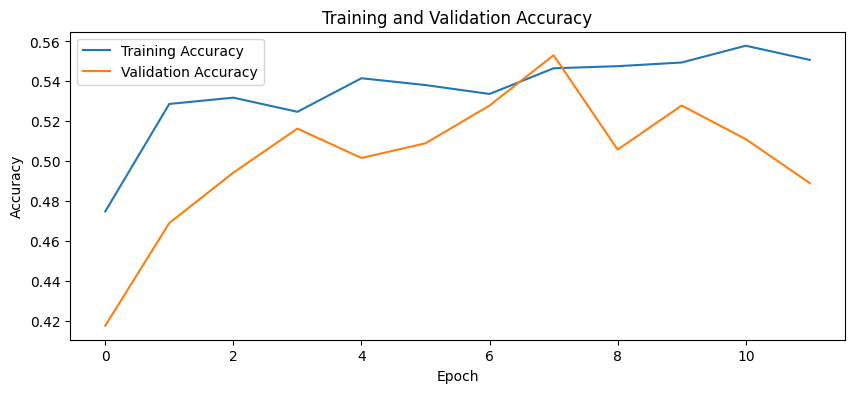

In [ ]:
# Shows accuracy over epochs
plt.figure(figsize=(10, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

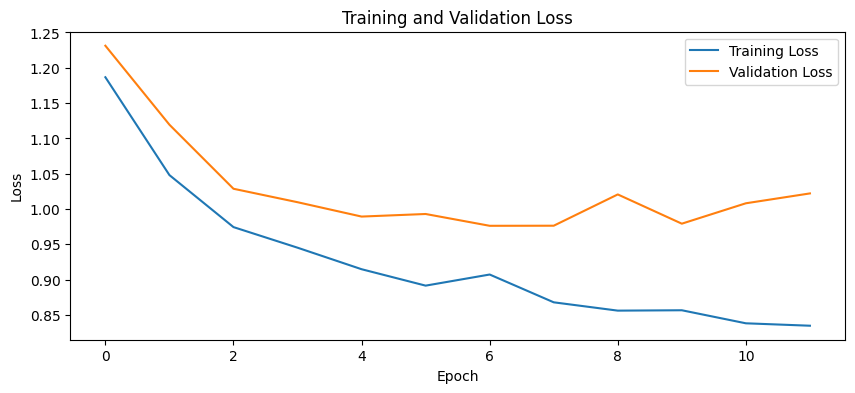

In [ ]:
# Shows loss over epochs
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Evaluate on the test set
testLoss, testAccuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", testLoss)
print("Test Accuracy:", testAccuracy)

Test Loss: 1.0038297176361084
Test Accuracy: 0.517241358757019


In [ ]:
# Make predictions
y_predProb = model.predict(X_test)
y_pred = np.argmax(y_predProb, axis=1)
y_true = np.argmax(y_test, axis=1)

print("First 20 predicted classes:")
print(y_pred[:20])

print("\nFirst 20 true classes:")
print(y_true[:20])

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
First 20 predicted classes:
[2 2 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 2 2 2]

First 20 true classes:
[1 1 2 1 1 3 3 3 1 1 3 3 3 3 1 3 0 1 1 1]


In [ ]:
# Classification Report
print("Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["low", "normal", "high", "heavy"]
))

Classification Report:
              precision    recall  f1-score   support

         low       0.42      0.45      0.44       190
      normal       0.78      0.36      0.49       640
        high       0.13      0.51      0.21        79
       heavy       0.66      0.92      0.77       280

    accuracy                           0.52      1189
   macro avg       0.50      0.56      0.48      1189
weighted avg       0.65      0.52      0.53      1189



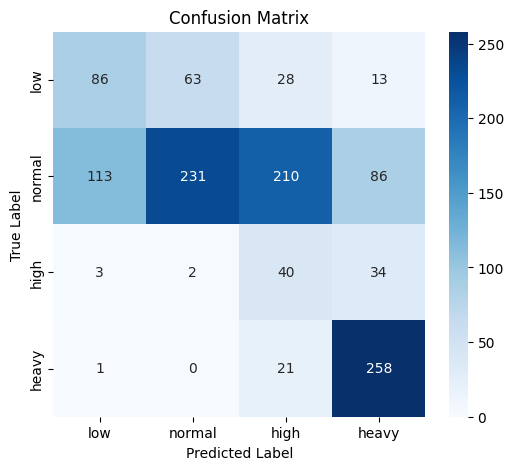

In [ ]:
# Confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["low", "normal", "high", "heavy"],
    yticklabels=["low", "normal", "high", "heavy"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()